# Models evaluation - Test 3 (Synthetic Copy)

Hello! This notebook documents the code that was written to evalutate the models on different capabilities. We also include results of the evaluations. 

Here we will be testing the models on the synthetic copy test - the models are tasked with processing a text composed of N true and M noise tokens (the noise tokens are uniform), and then with outputting the N true tokens.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
from tqdm.notebook import trange, tqdm
import matplotlib.pyplot as plt
import random

# Build vocab for all models & tests. 
# We employ the same vocab size to be fair 

vocab = dict()
device = "cuda"

characters = "ABCDEFGHIJKLMNOPQRSTUVWXYZ{}()[]|"

letters = "ABCDEFGHIJKLMNOPQRSTUVWXYZ"

for i in range(10):
    vocab[str(i)] = i

for char in characters:
    vocab[char] = len(vocab)

for i in range(100):
    vocab[f"NOISE_{i}"] = len(vocab)


vocab["<ENDSEQ>"] = len(vocab)
vocab["<STABLENOISE>"] = len(vocab)
vocab["<STARTTASK>"] = len(vocab)
vocab["<EOS>"] = len(vocab)

In [2]:
def get_batch_ex5(batch_size, vocab, lookup_size=5, pairs=25, device="cuda"):

    first_number_ix = vocab["0"]
    last_number_ix = vocab["9"]
    first_letter_ix = vocab["A"]
    last_letter_ix = vocab["Z"]

    strings = []
    target_strings = []

    for i in range(batch_size):
        string = []
        tracking_set = dict()
        for j in range(pairs):
            letter = random.randint(first_letter_ix, last_letter_ix)
            number = random.randint(first_number_ix, last_number_ix)
            string.append(letter)
            string.append(number)
            string.append(vocab["|"])
            tracking_set[letter] = number
        lookup_indeces = random.choices(list(tracking_set.keys()), k=lookup_size)
        string.append(vocab["<ENDSEQ>"])
        string.extend(lookup_indeces)
        #string.append(vocab["<STARTTASK>"])

        target_string = [tracking_set[letter_ix] for letter_ix in lookup_indeces]

        strings.append(string)
        target_strings.append(target_string)

    ready_tensor = torch.tensor(strings, device=device)
    copy_tensor = torch.tensor(target_strings, device=device)

    return F.one_hot(ready_tensor, num_classes=len(vocab)).float(), copy_tensor


def diagnose_ex5(model, copy_size, buffer_size, vocab, teacher_forcing=False):

    batch_size=1 #Analyzing one random sample
    batch, targets = get_batch_ex5(batch_size, vocab, copy_size, buffer_size)
    model_targets = F.one_hot(targets, num_classes=len(vocab)).float()

    logits, gates = model.predict_inference(
        x=batch,
        vocab=vocab,
        max_len=copy_size-1,
        diagnostic=True
    )

    tokens = torch.argmax(logits, dim=2) # (batch, seq)

    gates = {
        name: np.array(gate)
        for name, gate in gates.items()
    }

    fig, axes = plt.subplots(
        1,
        len(gates),
        figsize=(8 * len(gates), 8)
    )
    
    if len(gates) == 1:
        axes = [axes]
    
    vmin = min(gate.min() for gate in gates.values())
    vmax = max(gate.max() for gate in gates.values())
    
    for ax, (name, gate) in zip(axes, gates.items()):
        im = ax.imshow(
            gate.T,
            cmap="viridis",
            aspect="auto",
            vmin=vmin,
            vmax=vmax
        )
    
        ax.set_title(name)
        ax.set_xlabel("Step")
        ax.set_ylabel("Hidden dimension")
        fig.colorbar(im, ax=ax)
    
    plt.tight_layout()
    plt.show()

def diagnose_ex5_scalar_graph(model, copy_size, buffer_size, vocab, teacher_forcing=False):

    batch_size=1 #Analyzing one random sample
    batch, targets = get_batch_ex5(batch_size, vocab, copy_size, buffer_size)
    model_targets = F.one_hot(targets, num_classes=len(vocab)).float()

    logits, gates = model.predict_inference(
        x=batch,
        vocab=vocab,
        max_len=copy_size-1,
        diagnostic=True
    )

    tokens = torch.argmax(logits, dim=2) # (batch, seq)

    gates = {
        name: np.array(gate)
        for name, gate in gates.items()
    }

    fig, axes = plt.subplots(
        1,
        len(gates),
        figsize=(6 * len(gates), 5)
    )
    
    if len(gates) == 1:
        axes = [axes]
    
    for ax, (name, gate) in zip(axes, gates.items()):
        ax.plot(gate)
    
        ax.set_title(name)
        ax.set_xlabel("Step")
        ax.set_ylabel("Gate value")
        ax.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()


In [3]:
import custom_models
import math

hid=256
m_hid=16
emb=len(vocab)
lr=1e-3
batch_size=32
total_batches=14000
test_batches=10
copy_size=1
buffer_size=10

steps_history = []
train_history = []
test_history = []



sLSTM_model = custom_models.sLSTM(hid, emb, device="cuda")
opt_sLSTM = torch.optim.Adam(sLSTM_model.parameters(), lr=lr)

LSTM_model = custom_models.CopyLSTM(hid, emb, device="cuda")
opt_LSTM = torch.optim.Adam(LSTM_model.parameters(), lr=lr)

MGU_model = custom_models.MRRN(hid, emb, device="cuda")
opt_MGU = torch.optim.Adam(MGU_model.parameters(), lr=lr)

GRU_model = custom_models.CopyGRU(hid, emb, device="cuda")
opt_GRU = torch.optim.Adam(GRU_model.parameters(), lr=lr)

maGRU_model = custom_models.maGRU(hid, emb, device="cuda")
opt_maGRU = torch.optim.Adam(maGRU_model.parameters(), lr=lr)

eGRU_model = custom_models.eGRU(hid, emb, device="cuda")
opt_eGRU = torch.optim.Adam(eGRU_model.parameters(), lr=lr)

mLSTM_model = custom_models.mLSTM(m_hid, emb, device=device)
opt_mLSTM = torch.optim.Adam(mLSTM_model.parameters(), lr=lr)

mLSTMLite_model = custom_models.mLSTMLite(m_hid, emb, device=device)
opt_mLSTMLite = torch.optim.Adam(mLSTMLite_model.parameters(), lr=lr)

In [4]:
def load_model(filename, device, model, optimizer):
    checkpoint = torch.load(filename, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    start_epoch = checkpoint["epoch_saved"] + 1
    return start_epoch

In [5]:
hid=256
emb=len(vocab)
lr=1e-3
batch_size=32
test_batches=100

steps_history = []
train_history = []
test_history = []

In [6]:

load_model("./models/ex5/mLSTM_100_ex5_epoch_7000.pt", "cuda", mLSTM_model, opt_mLSTM)
load_model("./models/ex5/LSTM_100_ex5_epoch_7000.pt", "cuda", LSTM_model, opt_LSTM)
load_model("./models/ex5/mLSTMLite_100_ex5_epoch_7000.pt", "cuda", mLSTMLite_model, opt_mLSTMLite)
load_model("./models/ex5/sLSTM_100_ex5_epoch_7000.pt", "cuda", sLSTM_model, opt_sLSTM)
load_model("./models/ex5/MGU_100_ex5_epoch_7000.pt", "cuda", MGU_model, opt_MGU)
load_model("./models/ex5/maGRU_100_ex5_epoch_7000.pt", "cuda", maGRU_model, opt_maGRU)
load_model("./models/ex5/GRU_100_ex5_epoch_7000.pt", "cuda", GRU_model, opt_GRU)
load_model("./models/ex5/eGRU_100_ex5_epoch_7000.pt", "cuda", eGRU_model, opt_eGRU)

7001

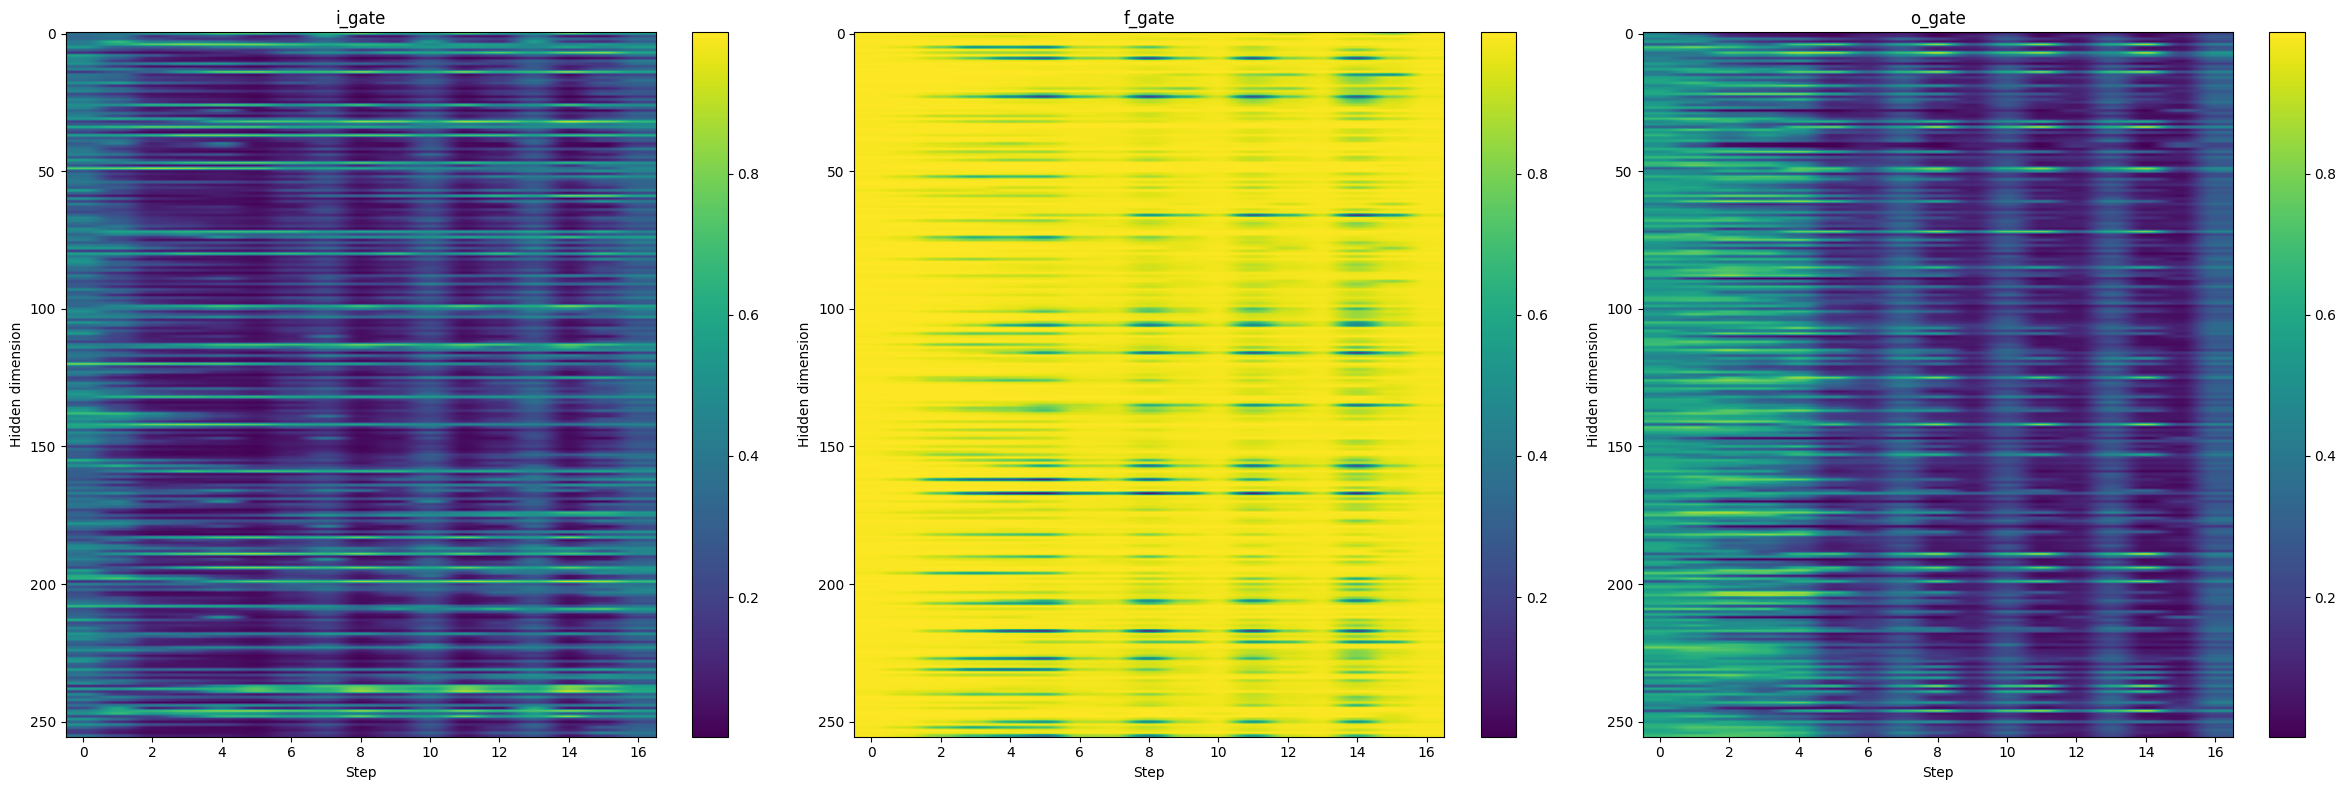

: 

In [ ]:
diagnose_ex5(LSTM_model, copy_size=1, buffer_size=5, vocab=vocab)

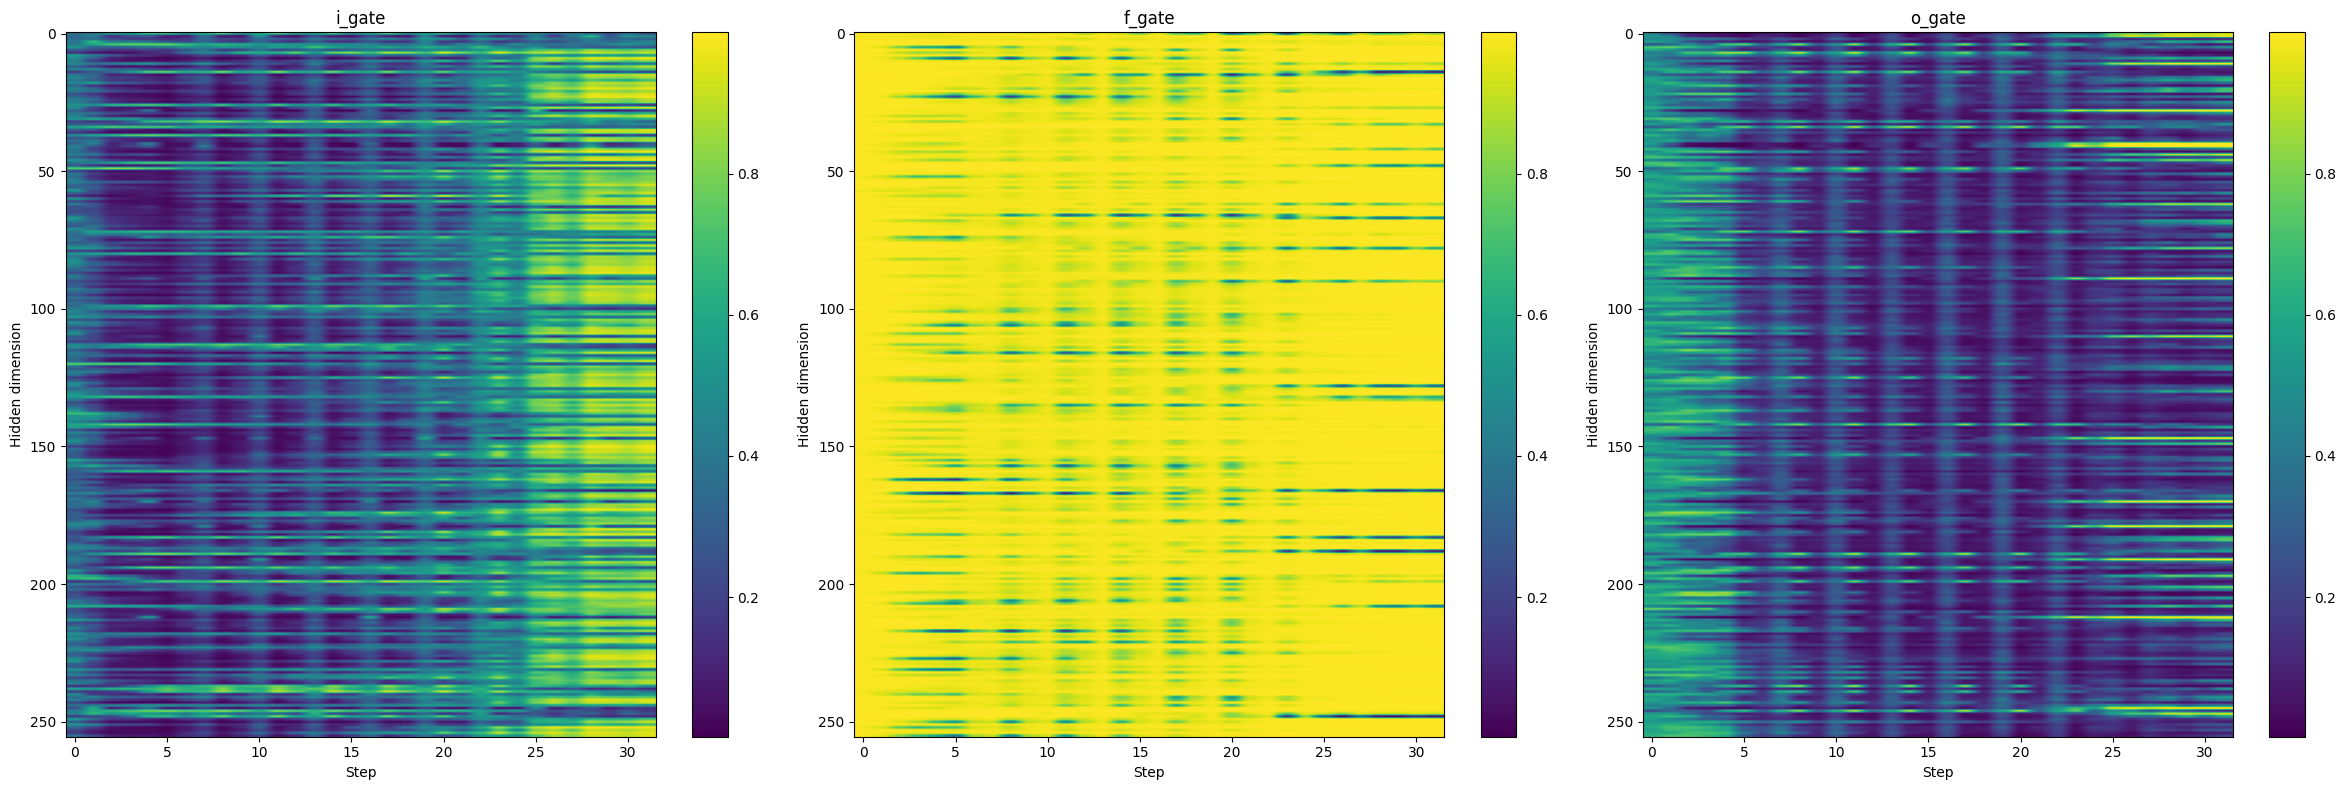

In [8]:
diagnose_ex5(LSTM_model, copy_size=1, buffer_size=10, vocab=vocab)

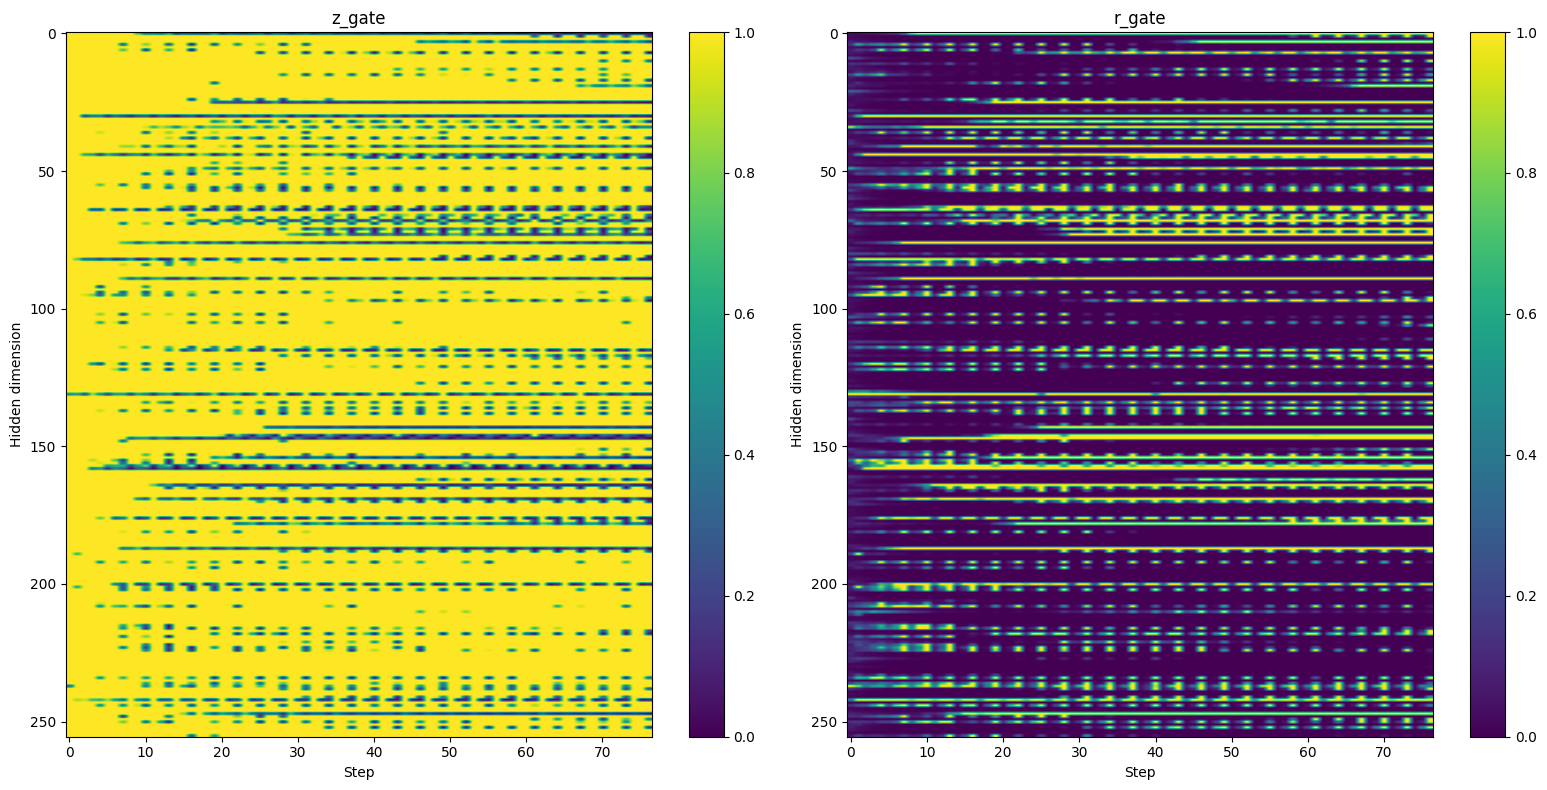

In [7]:
diagnose_ex5(eGRU_model, copy_size=1, buffer_size=25, vocab=vocab)

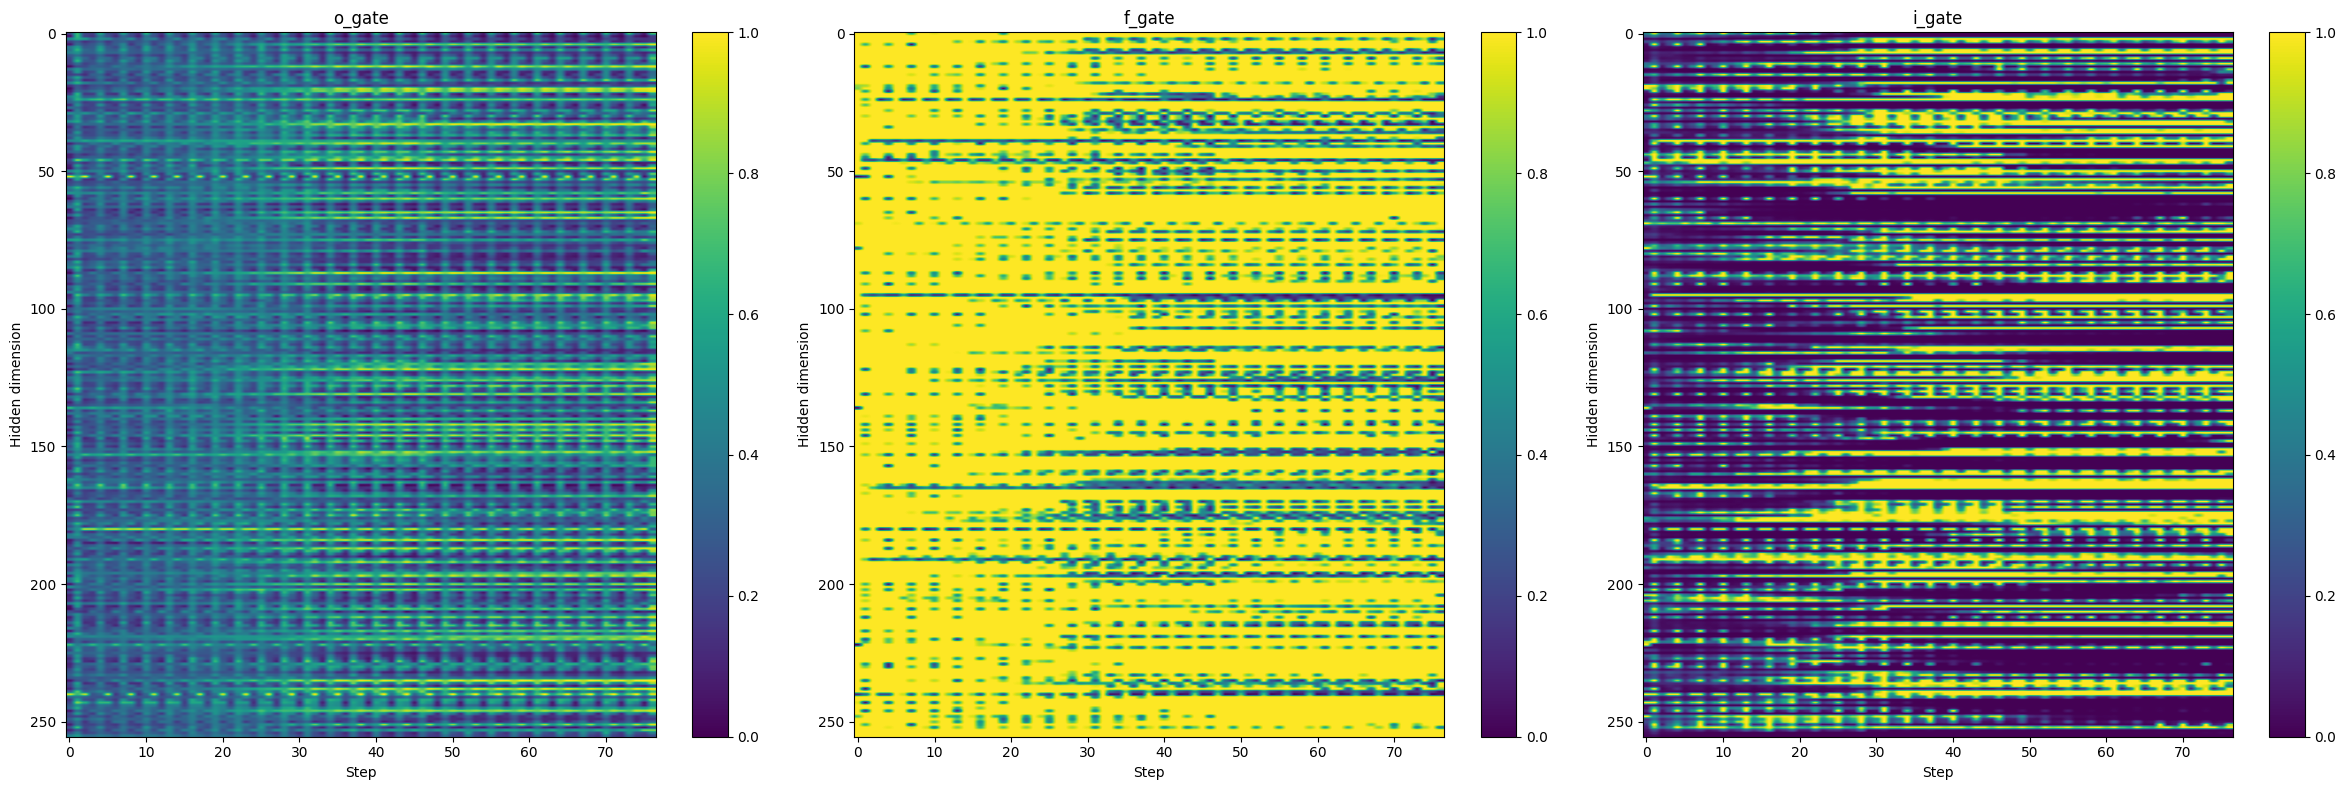

In [8]:
diagnose_ex5(sLSTM_model, copy_size=1, buffer_size=25, vocab=vocab)

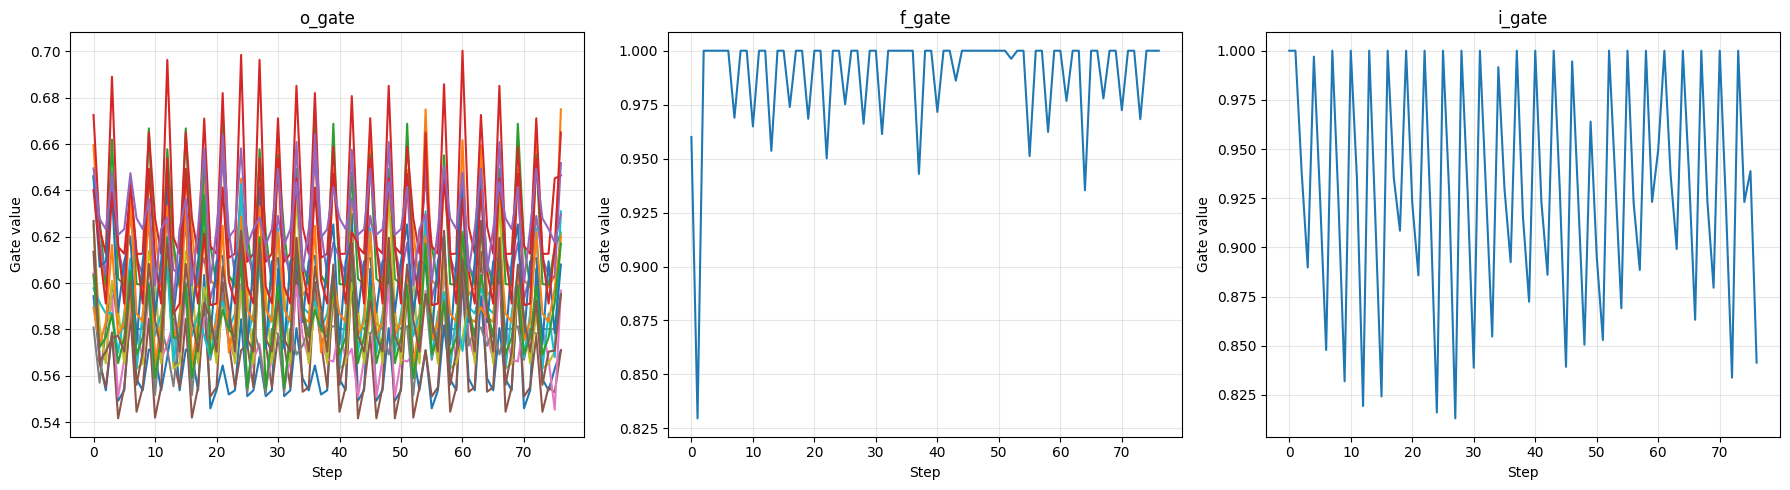

In [9]:
diagnose_ex5_scalar_graph(mLSTM_model, copy_size=1, buffer_size=25, vocab=vocab)

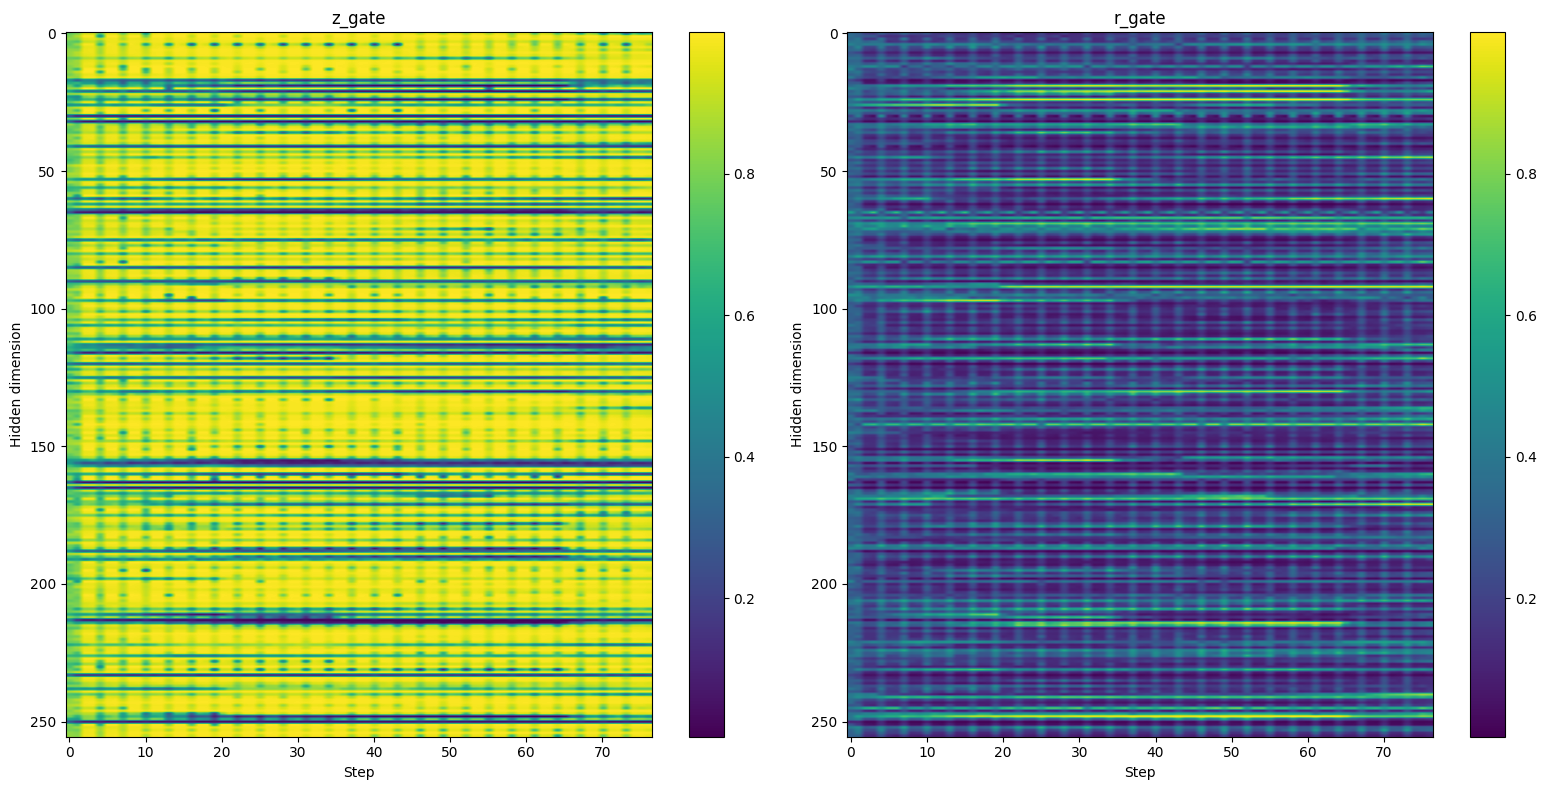

In [10]:
diagnose_ex5(GRU_model, copy_size=1, buffer_size=25, vocab=vocab)

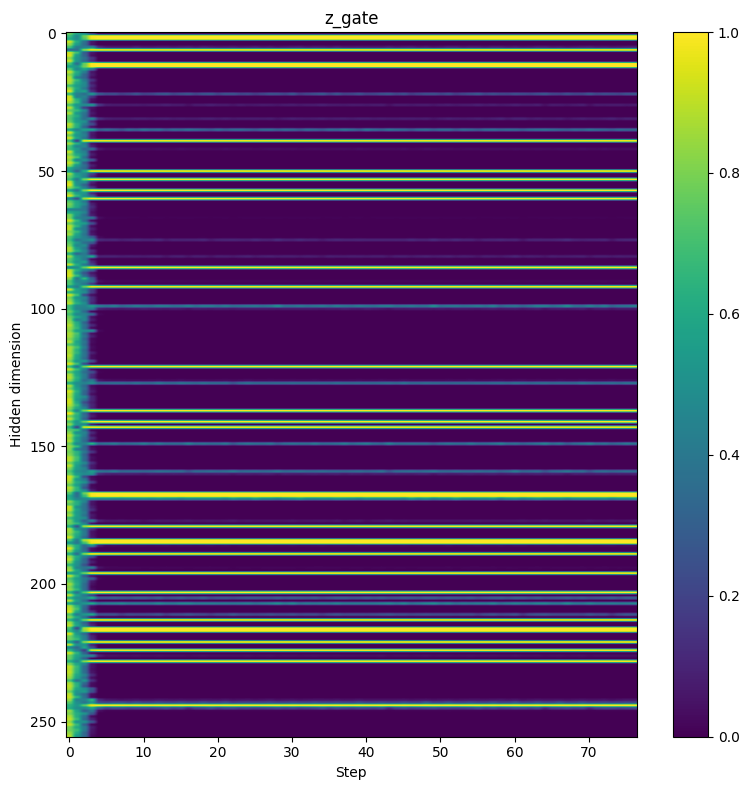

In [11]:
diagnose_ex5(MGU_model, copy_size=1, buffer_size=25, vocab=vocab)

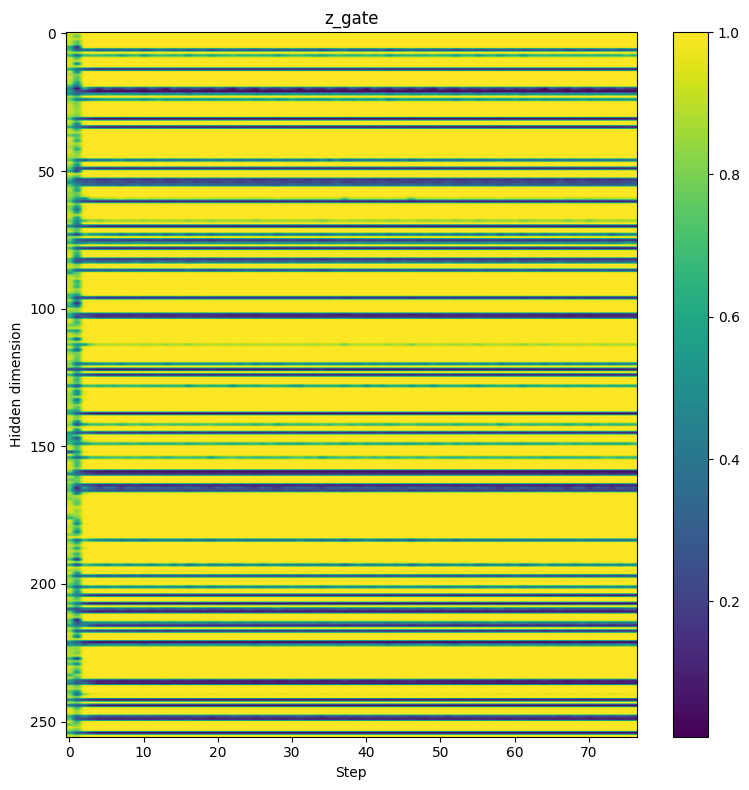

: 

In [ ]:
diagnose_ex5(maGRU_model, copy_size=1, buffer_size=25, vocab=vocab)

In [19]:
ex1_mlstm_50 =   evaluate_ex5(mLSTM_model, lookup_size=1, teacher_forcing=False, pairs=5,  total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_mlstm_100 =  evaluate_ex5(mLSTM_model, lookup_size=1, teacher_forcing=False, pairs=10, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_mlstm_250 =  evaluate_ex5(mLSTM_model, lookup_size=1, teacher_forcing=False, pairs=15, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_mlstm_500 =  evaluate_ex5(mLSTM_model, lookup_size=1, teacher_forcing=False, pairs=20, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_mlstm_750 =  evaluate_ex5(mLSTM_model, lookup_size=1, teacher_forcing=False, pairs=30, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_mlstm_1000 = evaluate_ex5(mLSTM_model, lookup_size=1, teacher_forcing=False, pairs=50, total_batches=test_batches, batch_size=batch_size, vocab=vocab)

print("mLSTM noise sorting difference at buffer_size=50: ",   ex1_mlstm_50)
print("mLSTM noise sorting difference at buffer_size=100: ",  ex1_mlstm_100)
print("mLSTM noise sorting difference at buffer_size=250: ",  ex1_mlstm_250)
print("mLSTM noise sorting difference at buffer_size=500: ",  ex1_mlstm_500)
print("mLSTM noise sorting difference at buffer_size=750: ",  ex1_mlstm_750)
print("mLSTM noise sorting difference at buffer_size=1000: ", ex1_mlstm_1000)

Testing model at  10  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  10  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  10  buffer_size.


...

Testing model at  10  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  10  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

mLSTM noise sorting difference at buffer_size=50:  0.6568688118811881
mLSTM noise sorting difference at buffer_size=100:  0.7298886138613861
mLSTM noise sorting difference at buffer_size=250:  0.7589727722772277
mLSTM noise sorting difference at buffer_size=500:  0.7778465346534653
mLSTM noise sorting difference at buffer_size=750:  0.8109529702970297
mLSTM noise sorting difference at buffer_size=1000:  0.8298267326732673


In [18]:
ex1_mlstmlite_50 =   evaluate_ex5(mLSTMLite_model, lookup_size=1, teacher_forcing=False, pairs=5,  total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_mlstmlite_100 =  evaluate_ex5(mLSTMLite_model, lookup_size=1, teacher_forcing=False, pairs=10, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_mlstmlite_250 =  evaluate_ex5(mLSTMLite_model, lookup_size=1, teacher_forcing=False, pairs=15, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_mlstmlite_500 =  evaluate_ex5(mLSTMLite_model, lookup_size=1, teacher_forcing=False, pairs=20, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_mlstmlite_750 =  evaluate_ex5(mLSTMLite_model, lookup_size=1, teacher_forcing=False, pairs=30, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_mlstmlite_1000 = evaluate_ex5(mLSTMLite_model, lookup_size=1, teacher_forcing=False, pairs=50, total_batches=test_batches, batch_size=batch_size, vocab=vocab)

print("mLSTMLite noise sorting difference at buffer_size=50: ",   ex1_mlstmlite_50)
print("mLSTMLite noise sorting difference at buffer_size=100: ",  ex1_mlstmlite_100)
print("mLSTMLite noise sorting difference at buffer_size=250: ",  ex1_mlstmlite_250)
print("mLSTMLite noise sorting difference at buffer_size=500: ",  ex1_mlstmlite_500)
print("mLSTMLite noise sorting difference at buffer_size=750: ",  ex1_mlstmlite_750)
print("mLSTMLite noise sorting difference at buffer_size=1000: ", ex1_mlstmlite_1000)

Testing model at  10  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  10  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  10  buffer_size.


...

Testing model at  10  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  10  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

mLSTMLite noise sorting difference at buffer_size=50:  0.650680693069307
mLSTMLite noise sorting difference at buffer_size=100:  0.7165841584158416
mLSTMLite noise sorting difference at buffer_size=250:  0.7509282178217822
mLSTMLite noise sorting difference at buffer_size=500:  0.7691831683168316
mLSTMLite noise sorting difference at buffer_size=750:  0.812809405940594
mLSTMLite noise sorting difference at buffer_size=1000:  0.8220915841584159


In [20]:
ex1_cgru_50 =   evaluate_ex5(GRU_model, lookup_size=1, teacher_forcing=False, pairs=5,  total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_cgru_100 =  evaluate_ex5(GRU_model, lookup_size=1, teacher_forcing=False, pairs=10, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_cgru_250 =  evaluate_ex5(GRU_model, lookup_size=1, teacher_forcing=False, pairs=15, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_cgru_500 =  evaluate_ex5(GRU_model, lookup_size=1, teacher_forcing=False, pairs=20, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_cgru_750 =  evaluate_ex5(GRU_model, lookup_size=1, teacher_forcing=False, pairs=30, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_cgru_1000 = evaluate_ex5(GRU_model, lookup_size=1, teacher_forcing=False, pairs=50, total_batches=test_batches, batch_size=batch_size, vocab=vocab)

print("GRU noise sorting difference at buffer_size=50: ", ex1_cgru_50)
print("GRU noise sorting difference at buffer_size=100: ", ex1_cgru_100)
print("GRU noise sorting difference at buffer_size=250: ", ex1_cgru_250)
print("GRU noise sorting difference at buffer_size=500: ", ex1_cgru_500)
print("GRU noise sorting difference at buffer_size=750: ", ex1_cgru_750)
print("GRU noise sorting difference at buffer_size=1000: ", ex1_cgru_1000)

Testing model at  10  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  10  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  10  buffer_size.


...

Testing model at  10  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  10  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

GRU noise sorting difference at buffer_size=50:  0.6466584158415841
GRU noise sorting difference at buffer_size=100:  0.7441212871287128
GRU noise sorting difference at buffer_size=250:  0.7685643564356436
GRU noise sorting difference at buffer_size=500:  0.7908415841584159
GRU noise sorting difference at buffer_size=750:  0.8131188118811881
GRU noise sorting difference at buffer_size=1000:  0.8152846534653465


In [21]:
ex1_mgu_50 =   evaluate_ex5(MGU_model, lookup_size=1, teacher_forcing=False, pairs=5,   total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_mgu_100 =  evaluate_ex5(MGU_model, lookup_size=1, teacher_forcing=False, pairs=10, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_mgu_250 =  evaluate_ex5(MGU_model, lookup_size=1, teacher_forcing=False, pairs=15, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_mgu_500 =  evaluate_ex5(MGU_model, lookup_size=1, teacher_forcing=False, pairs=20, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_mgu_750 =  evaluate_ex5(MGU_model, lookup_size=1, teacher_forcing=False, pairs=30, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_mgu_1000 = evaluate_ex5(MGU_model, lookup_size=1, teacher_forcing=False, pairs=50, total_batches=test_batches, batch_size=batch_size, vocab=vocab)

print("MGU noise sorting difference at buffer_size=50: ",   ex1_mgu_50)
print("MGU noise sorting difference at buffer_size=100: ",  ex1_mgu_100)
print("MGU noise sorting difference at buffer_size=250: ",  ex1_mgu_250)
print("MGU noise sorting difference at buffer_size=500: ",  ex1_mgu_500)
print("MGU noise sorting difference at buffer_size=750: ",  ex1_mgu_750)
print("MGU noise sorting difference at buffer_size=1000: ", ex1_mgu_1000)

Testing model at  10  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  10  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  10  buffer_size.


...

Testing model at  10  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  10  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

MGU noise sorting difference at buffer_size=50:  0.7945544554455446
MGU noise sorting difference at buffer_size=100:  0.8483910891089109
MGU noise sorting difference at buffer_size=250:  0.8737623762376238
MGU noise sorting difference at buffer_size=500:  0.8845915841584159
MGU noise sorting difference at buffer_size=750:  0.8845915841584159
MGU noise sorting difference at buffer_size=1000:  0.8972772277227723


In [22]:
ex1_slstm_50 =   evaluate_ex5(sLSTM_model, lookup_size=1, teacher_forcing=False, pairs=5,   total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_slstm_100 =  evaluate_ex5(sLSTM_model, lookup_size=1, teacher_forcing=False, pairs=10, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_slstm_250 =  evaluate_ex5(sLSTM_model, lookup_size=1, teacher_forcing=False, pairs=15, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_slstm_500 =  evaluate_ex5(sLSTM_model, lookup_size=1, teacher_forcing=False, pairs=20, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_slstm_750 =  evaluate_ex5(sLSTM_model, lookup_size=1, teacher_forcing=False, pairs=30, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_slstm_1000 = evaluate_ex5(sLSTM_model, lookup_size=1, teacher_forcing=False, pairs=50, total_batches=test_batches, batch_size=batch_size, vocab=vocab)

print("sLSTM noise sorting difference at buffer_size=50: ",   ex1_slstm_50)
print("sLSTM noise sorting difference at buffer_size=100: ",  ex1_slstm_100)
print("sLSTM noise sorting difference at buffer_size=250: ",  ex1_slstm_250)
print("sLSTM noise sorting difference at buffer_size=500: ",  ex1_slstm_500)
print("sLSTM noise sorting difference at buffer_size=750: ",  ex1_slstm_750)
print("sLSTM noise sorting difference at buffer_size=1000: ", ex1_slstm_1000)

Testing model at  10  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  10  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  10  buffer_size.


...

Testing model at  10  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  10  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

sLSTM noise sorting difference at buffer_size=50:  0.6534653465346535
sLSTM noise sorting difference at buffer_size=100:  0.7342202970297029
sLSTM noise sorting difference at buffer_size=250:  0.7883663366336634
sLSTM noise sorting difference at buffer_size=500:  0.8189975247524752
sLSTM noise sorting difference at buffer_size=750:  0.854269801980198
sLSTM noise sorting difference at buffer_size=1000:  0.885519801980198


In [23]:
ex1_magru_50 =   evaluate_ex5(maGRU_model, lookup_size=1, teacher_forcing=False, pairs=5,   total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_magru_100 =  evaluate_ex5(maGRU_model, lookup_size=1, teacher_forcing=False, pairs=10, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_magru_250 =  evaluate_ex5(maGRU_model, lookup_size=1, teacher_forcing=False, pairs=15, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_magru_500 =  evaluate_ex5(maGRU_model, lookup_size=1, teacher_forcing=False, pairs=20, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_magru_750 =  evaluate_ex5(maGRU_model, lookup_size=1, teacher_forcing=False, pairs=30, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_magru_1000 = evaluate_ex5(maGRU_model, lookup_size=1, teacher_forcing=False, pairs=50, total_batches=test_batches, batch_size=batch_size, vocab=vocab)

print("maGRU noise sorting difference at buffer_size=50: ",   ex1_magru_50)
print("maGRU noise sorting difference at buffer_size=100: ",  ex1_magru_100)
print("maGRU noise sorting difference at buffer_size=250: ",  ex1_magru_250)
print("maGRU noise sorting difference at buffer_size=500: ",  ex1_magru_500)
print("maGRU noise sorting difference at buffer_size=750: ",  ex1_magru_750)
print("maGRU noise sorting difference at buffer_size=1000: ", ex1_magru_1000)

Testing model at  10  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  10  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  10  buffer_size.


...

Testing model at  10  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  10  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

maGRU noise sorting difference at buffer_size=50:  0.7323638613861386
maGRU noise sorting difference at buffer_size=100:  0.8211633663366337
maGRU noise sorting difference at buffer_size=250:  0.8524133663366337
maGRU noise sorting difference at buffer_size=500:  0.8722153465346535
maGRU noise sorting difference at buffer_size=750:  0.8898514851485149
maGRU noise sorting difference at buffer_size=1000:  0.8889232673267327


In [24]:
ex1_eGRU_50 =   evaluate_ex5(eGRU_model, lookup_size=1, teacher_forcing=False, pairs=5,   total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_eGRU_100 =  evaluate_ex5(eGRU_model, lookup_size=1, teacher_forcing=False, pairs=10, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_eGRU_250 =  evaluate_ex5(eGRU_model, lookup_size=1, teacher_forcing=False, pairs=15, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_eGRU_500 =  evaluate_ex5(eGRU_model, lookup_size=1, teacher_forcing=False, pairs=20, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_eGRU_750 =  evaluate_ex5(eGRU_model, lookup_size=1, teacher_forcing=False, pairs=30, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_eGRU_1000 = evaluate_ex5(eGRU_model, lookup_size=1, teacher_forcing=False, pairs=50, total_batches=test_batches, batch_size=batch_size, vocab=vocab)

print("eGRU noise sorting difference at buffer_size=50: ",   ex1_eGRU_50)
print("eGRU noise sorting difference at buffer_size=100: ",  ex1_eGRU_100)
print("eGRU noise sorting difference at buffer_size=250: ",  ex1_eGRU_250)
print("eGRU noise sorting difference at buffer_size=500: ",  ex1_eGRU_500)
print("eGRU noise sorting difference at buffer_size=750: ",  ex1_eGRU_750)
print("eGRU noise sorting difference at buffer_size=1000: ", ex1_eGRU_1000)

Testing model at  10  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  10  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  10  buffer_size.


...

Testing model at  10  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  10  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

eGRU noise sorting difference at buffer_size=50:  0.6531559405940595
eGRU noise sorting difference at buffer_size=100:  0.7453589108910891
eGRU noise sorting difference at buffer_size=250:  0.7954826732673267
eGRU noise sorting difference at buffer_size=500:  0.8276608910891089
eGRU noise sorting difference at buffer_size=750:  0.8536509900990099
eGRU noise sorting difference at buffer_size=1000:  0.8830445544554455


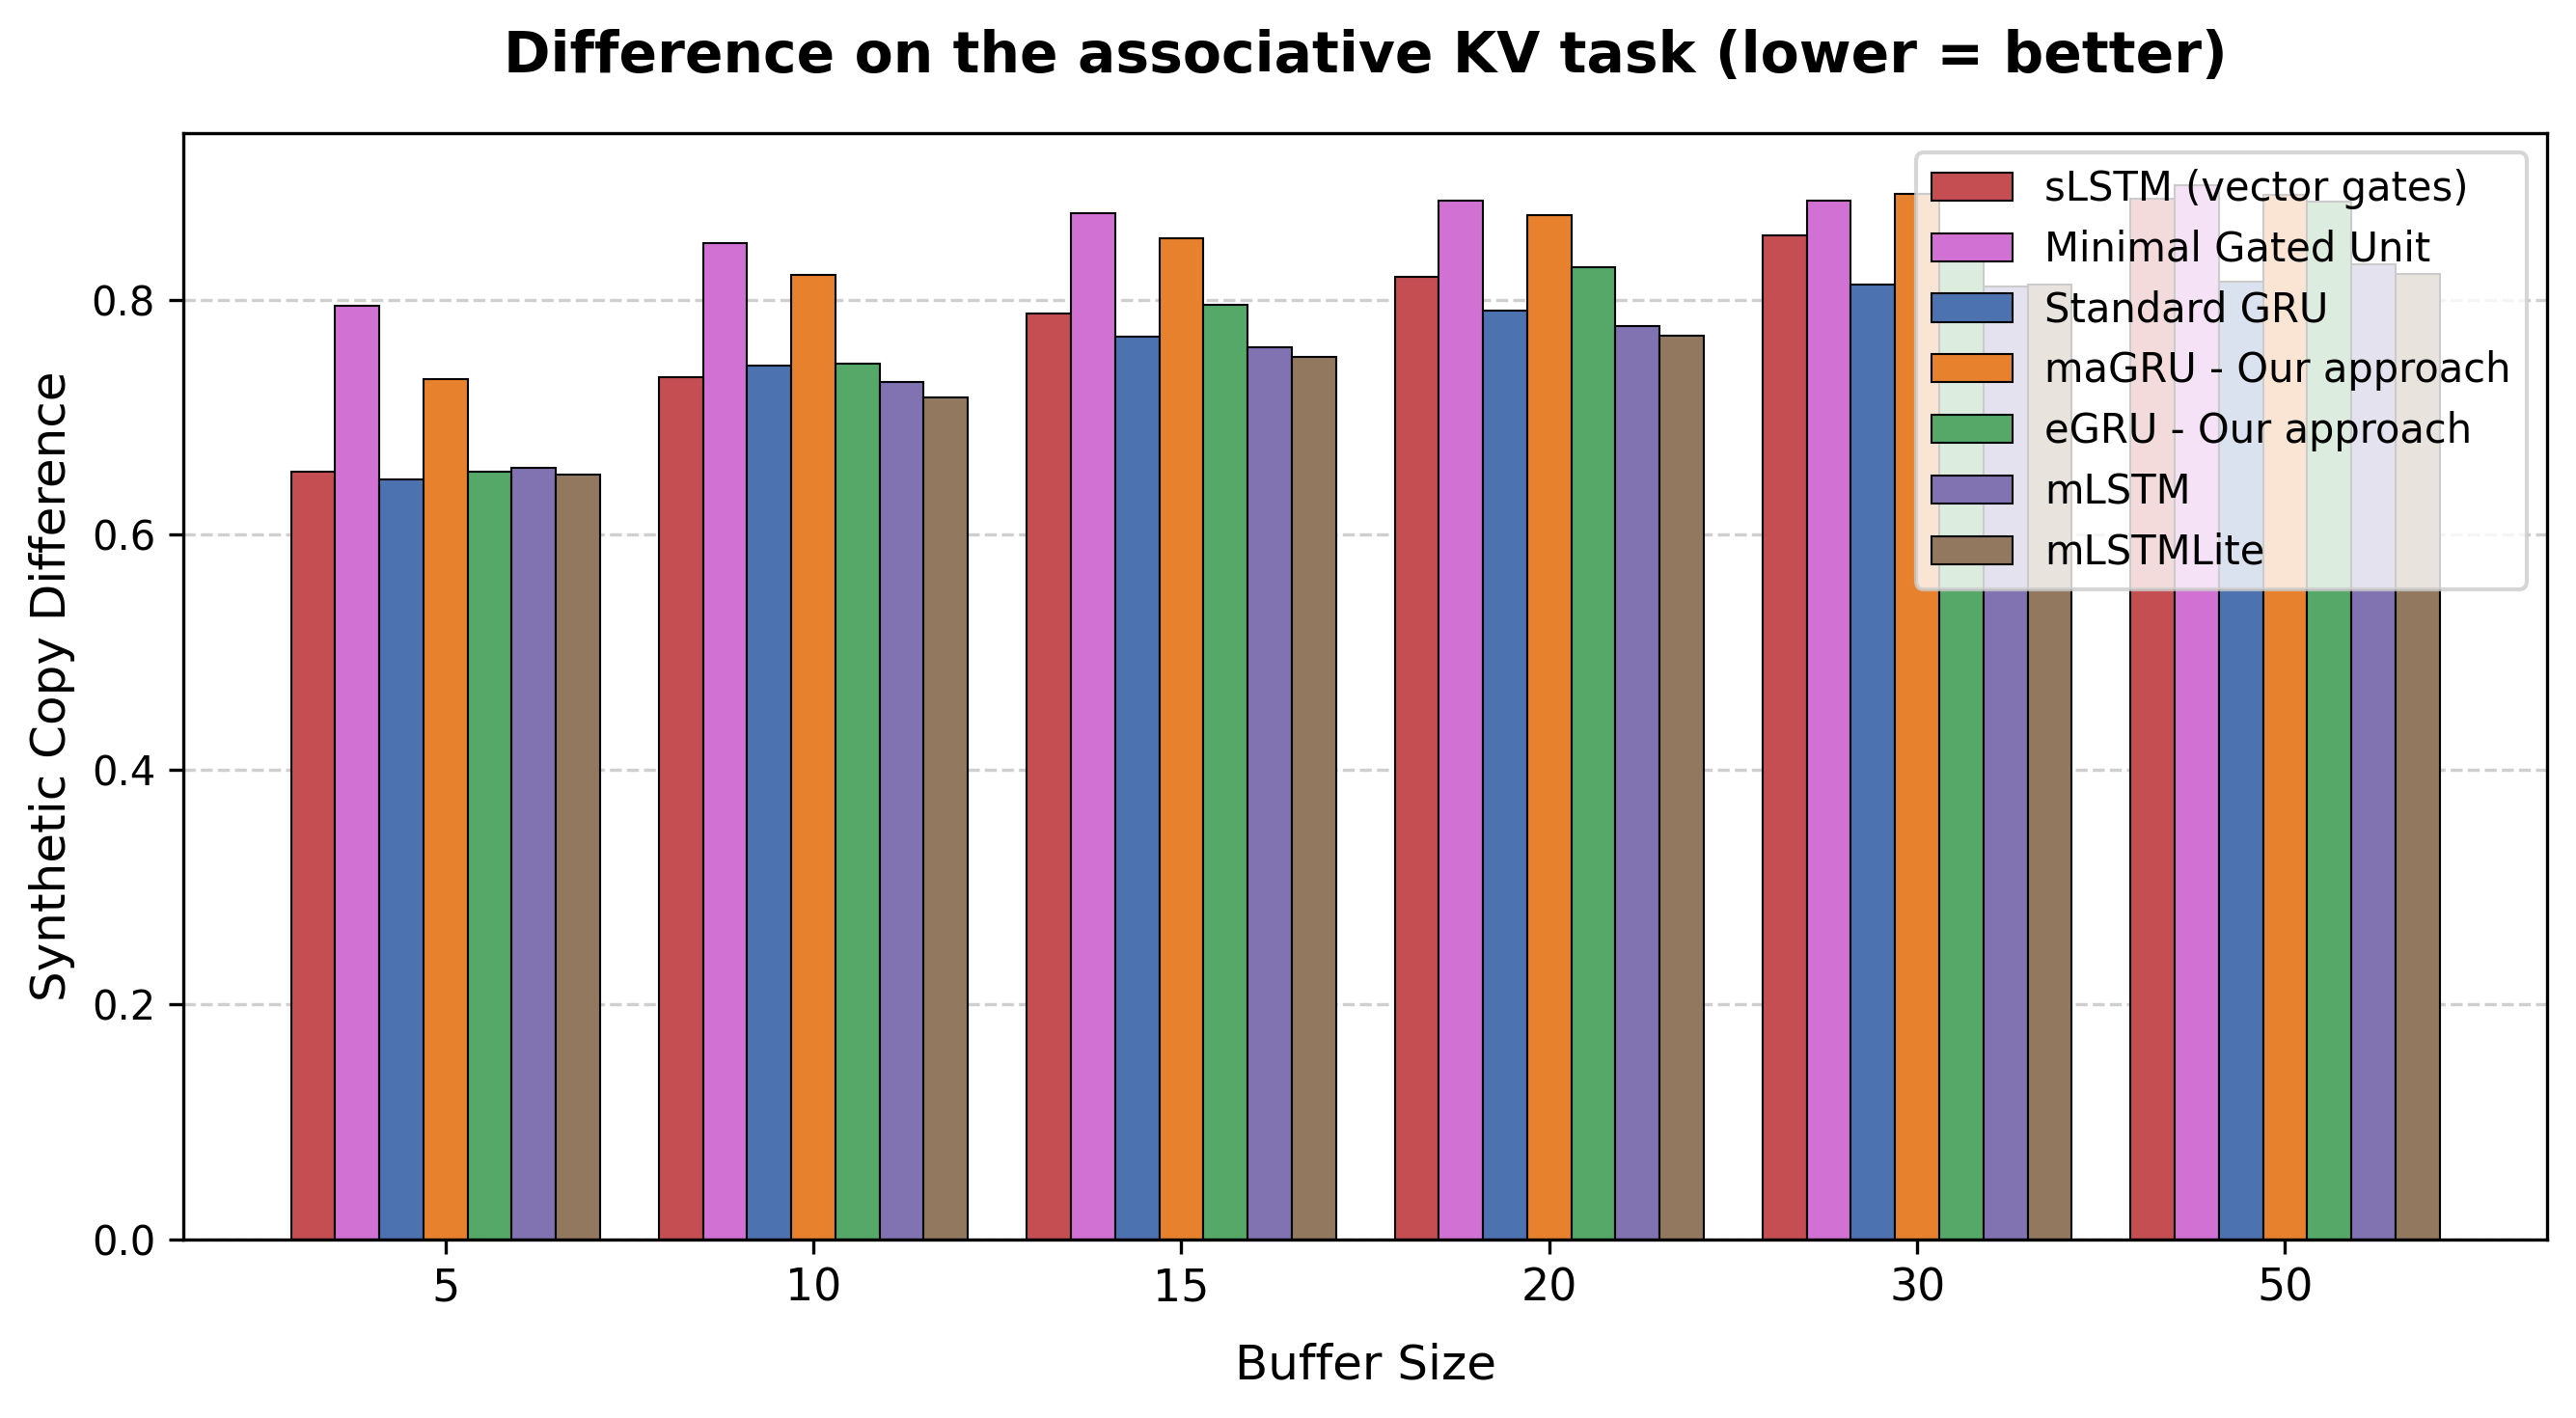

In [25]:
standard_gru = [
    0.6466584158415841,
     0.7441212871287128,
     0.7685643564356436,
     0.7908415841584159,
     0.8131188118811881,
      0.8152846534653465
]

egru = [
    0.6531559405940595,
     0.7453589108910891,
     0.7954826732673267,
     0.8276608910891089,
     0.8536509900990099,
      0.8830445544554455
]

magru = [
    0.7323638613861386,
     0.8211633663366337,
     0.8524133663366337,
     0.8722153465346535,
     0.8898514851485149,
      0.8889232673267327
]

MGU = [
    0.7945544554455446,
     0.8483910891089109,
     0.8737623762376238,
     0.8845915841584159,
     0.8845915841584159,
      0.8972772277227723
]

sLSTM = [
    0.6534653465346535,
     0.7342202970297029,
     0.7883663366336634,
     0.8189975247524752,
     0.854269801980198,
      0.885519801980198
]

mLSTM = [
    0.6568688118811881,
     0.7298886138613861,
     0.7589727722772277,
     0.7778465346534653,
     0.8109529702970297,
      0.8298267326732673
]
mLSTMLite = [
 0.650680693069307,
  0.7165841584158416,
  0.7509282178217822,
  0.7691831683168316,
  0.812809405940594,
   0.8220915841584159
]


import matplotlib.pyplot as plt
import numpy as np

# Data
buffer_sizes = ["5", "10", "15", "20", "30", "50"]

# Plot setup
x = np.arange(len(buffer_sizes))

# 7 bars -> slightly narrower
width = 0.12

fig, ax = plt.subplots(figsize=(9, 5), dpi=300)

# Create bars
rects0 = ax.bar(
    x - 3 * width,
    sLSTM,
    width,
    label="sLSTM (vector gates)",
    color="#C44E52",
    edgecolor="black",
    linewidth=0.5,
)

rects1 = ax.bar(
    x - 2 * width,
    MGU,
    width,
    label="Minimal Gated Unit",
    color="#D071D3",
    edgecolor="black",
    linewidth=0.5,
)

rects2 = ax.bar(
    x - width,
    standard_gru,
    width,
    label="Standard GRU",
    color="#4C72B0",
    edgecolor="black",
    linewidth=0.5,
)

rects3 = ax.bar(
    x,
    magru,
    width,
    label="maGRU - Our approach",
    color="#E7812E",
    edgecolor="black",
    linewidth=0.5,
)

rects4 = ax.bar(
    x + width,
    egru,
    width,
    label="eGRU - Our approach",
    color="#55A868",
    edgecolor="black",
    linewidth=0.5,
)

rects5 = ax.bar(
    x + 2 * width,
    mLSTM,
    width,
    label="mLSTM",
    color="#8172B2",
    edgecolor="black",
    linewidth=0.5,
)

rects6 = ax.bar(
    x + 3 * width,
    mLSTMLite,
    width,
    label="mLSTMLite",
    color="#937860",
    edgecolor="black",
    linewidth=0.5,
)


# Titles and labels
ax.set_title(
    "Difference on the associative KV task (lower = better)",
    fontsize=14,
    fontweight="bold",
    pad=15,
)

ax.set_xlabel(
    "Buffer Size",
    fontsize=12,
    fontweight="medium",
    labelpad=8,
)

ax.set_ylabel(
    "Synthetic Copy Difference",
    fontsize=12,
    fontweight="medium",
)

ax.set_xticks(x)
ax.set_xticklabels(buffer_sizes, fontsize=11)

# Aesthetics
ax.legend(fontsize=10, frameon=True)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.6,
)

ax.set_axisbelow(True)

plt.tight_layout()
plt.show()
